**Context & Motivation**

ONGC (Oil and Natural Gas Corporation) is India's largest state-owned oil producer, making it highly sensitive to global crude oil price movements. This analysis examines ONGC's stock behavior during the Iran-USA geopolitical tensions of late 2025 to early 2026, a period marked by rising conflict risk in the Middle East which directly threatened global oil supply chains.
Since Iran is a major crude oil exporter, any escalation raises fears of supply disruption, typically causing crude prices to spike. As a downstream beneficiary of higher oil prices, ONGC's stock tends to rally in such environments.
What this notebook explores:

ONGC price trend during the tension period
SMA20 and SMA50 crossover signals to identify momentum shifts
Visual correlation between crude oil prices and ONGC stock
How macroeconomic and geopolitical events translate into tradeable signals

This is a practical example of event-driven analysis — one of the core strategies used in quantitative finance and algorithmic trading.

Price            Close        High         Low        Open    Volume
Ticker         ONGC.NS     ONGC.NS     ONGC.NS     ONGC.NS   ONGC.NS
Date                                                                
2025-12-01  239.201202  240.197756  237.423038  238.439136   6307936
2025-12-02  237.940857  240.598324  236.924774  237.901783   5413988
2025-12-03  234.501785  238.742002  234.052354  238.439132  11829802
2025-12-04  236.660965  237.120161  234.179368  234.970743  10825420
2025-12-05  235.683960  237.608670  235.371325  237.120165   7645591


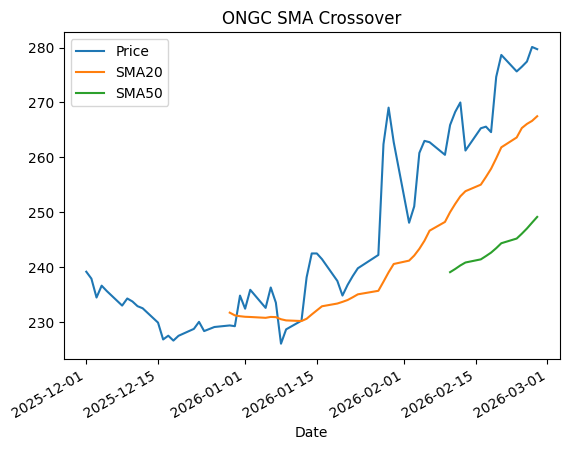

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ONGC on NSE
data = yf.download('ONGC.NS', start='2025-12-01', end='2026-03-01', progress=False)

print(data.head())

if data.empty:
    print("Data download failed")
else:
    close = data['Close'].squeeze()

    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()

    df = pd.DataFrame({
        'Price': close,
        'SMA20': sma20,
        'SMA50': sma50
    })

    df.plot(title='ONGC SMA Crossover')
    plt.show()

**#This is to analyse Ongc stock price and its moving averages to identify potential buy/sell signals based on the crossover of the 20-day and 50-day simple moving averages (SMA),** 
**# During USA israel vs Iran conflict.**


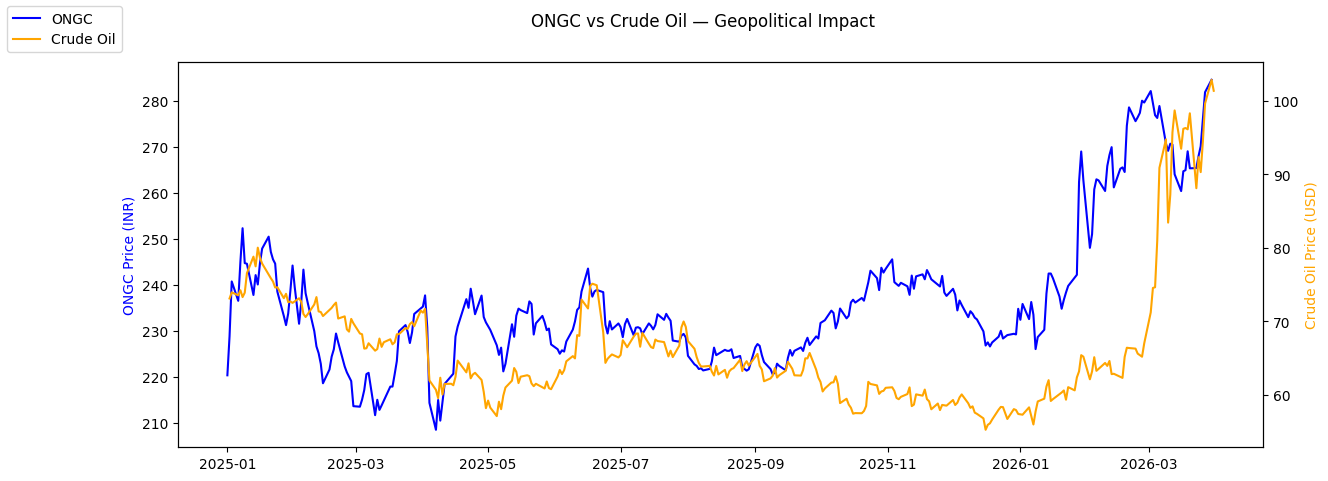

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ongc = yf.download('ONGC.NS', start='2025-01-01', end='2026-04-01', progress=False)['Close'].squeeze()
crude = yf.download('CL=F', start='2025-01-01', end='2026-04-01', progress=False)['Close'].squeeze()  # WTI Crude futures

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(ongc, color='blue', label='ONGC')
ax1.set_ylabel('ONGC Price (INR)', color='blue')

ax2 = ax1.twinx()
ax2.plot(crude, color='orange', label='Crude Oil')
ax2.set_ylabel('Crude Oil Price (USD)', color='orange')

fig.suptitle('ONGC vs Crude Oil — Geopolitical Impact')
fig.legend(loc='upper left')
plt.show()

**1. Early 2025 (Jan–Apr) — Both fall together**

Crude dropped from ~$80 to ~$60
ONGC followed, falling from ₹250 to ₹210
Strong correlation here 

**2. Mid 2025 (Apr–Nov) — Decoupling**

Crude stayed flat/low around $60–65
But ONGC slowly recovered to ₹240+
This suggests domestic factors (govt policy, dividends, buying) supported ONGC even when crude was weak

**3. Late 2025 to 2026 (Dec–Apr) — The Iran-US effect**

Crude exploded from ~$62 to ~$100 — massive spike
ONGC surged from ₹230 to ₹283 — nearly 23% gain
Both move sharply together again — classic geopolitical oil shock

Correlation: 0.48


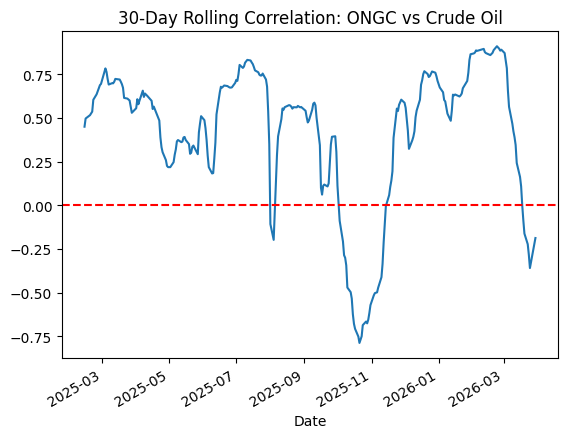

In [9]:
import numpy as np

# Combine into one DataFrame
combined = pd.DataFrame({'ONGC': ongc, 'Crude': crude}).dropna()

# Correlation coefficient
corr = combined['ONGC'].corr(combined['Crude'])
print(f"Correlation: {corr:.2f}")

# Rolling 30-day correlation to see how it changes over time
combined['Rolling_Corr'] = combined['ONGC'].rolling(30).corr(combined['Crude'])
combined['Rolling_Corr'].plot(title='30-Day Rolling Correlation: ONGC vs Crude Oil')
plt.axhline(0, color='red', linestyle='--')
plt.show()

**Phase 1: Jan–Jun 2025 → Correlation 0.5–0.8**
Normal tracking, moderate correlation
Oil markets had a strong start to 2025 driven by tougher US sanctions on Russia disrupting supplies to major buyers like India and China, plus Ukrainian drone strikes on Russian infrastructure disrupting Kazakhstan's oil exports. CNBC ONGC tracked crude reasonably well during this period of genuine supply uncertainty.

**Phase 2: Jul–Aug 2025 → Drops to -0.2**
Crude falls, ONGC holds — decoupling begins
OPEC+ agreed in early August to raise production by another 547,000 barrels per day in September, fully unwinding the 2.2 million barrel/day cuts agreed since November 2023, causing Brent crude futures to slip to around $67/barrel. IEA
The EIA forecast Brent crude to decline from over $70/barrel in July to around $58/barrel by Q4 2025, citing OPEC+ supply growth outpacing demand. U.S. Energy Information Administration
So crude was being hammered by oversupply fears, but ONGC held up — likely due to domestic institutional buying and dividend expectations.

**Phase 3: Sep–Nov 2025 → Crashes to -0.75**
The sharpest decoupling — real news explains it
Three things hit simultaneously:
A) Global crude kept falling: OPEC+ production target increases created prospects of an oversupplied market, with global production outpacing consumption throughout 2025 and implied stock builds of over 2.5 million barrels per day in the final two quarters — the largest since 2000 outside of 2020. U.S. Energy Information Administration
B) Axis Capital sell rating: ONGC shares fell over 3% after Axis Capital initiated coverage with a sell rating and a ₹205 target, citing production decline, weak oil price outlook, and high subsidiary debt, implying about 14% downside. MunafaSutra
C) Weak Q2 earnings reaction: ONGC shares slipped to ₹246 after reporting Q2 FY26 results — revenue slipped marginally by 0.89% to ₹1,57,911 crore, disappointing investors despite a 5.3% profit growth and a 29% EBITDA surge. Upstox
So crude was falling due to OPEC oversupply, but ONGC was falling for its own domestic reasons — hence the -0.75 inverse correlation. They were both falling but for completely different reasons at different rates.

**Phase 4: Dec 2025–Mar 2026 → Surges to 0.85**
Iran-US conflict forces re-correlation
Oil flows through the Strait of Hormuz were disrupted by the Middle East conflict, with Iraq, Saudi Arabia, Kuwait, UAE, Qatar, and Bahrain collectively shutting in an estimated 7.5–9.1 million barrels per day of crude oil production, pushing Brent crude to $103/barrel in March. U.S. Energy Information Administration
This supply shock was so massive it overrode everything — ONGC snapped back into tight correlation with crude instantly.

In [10]:
# Save all figures
for i, fig in enumerate(map(plt.figure, plt.get_fignums())):
    fig.savefig(f'chart_{i+1}.png', dpi=150, bbox_inches='tight')
print("All charts saved!")

All charts saved!
